In [1]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import _shared

_shared = importlib.reload(_shared)
build_transmission_model = _shared.build_transmission_model
#_shared.ensure_opacity_data(download=True)

# Use a coarse setup so the documentation notebook runs quickly.
context = build_transmission_model(
    include_cia=False,
    include_rayleigh=False,
    download=False,
    nlayers=40,
 )
tm = context['tm']

Numba not installed, using numpy instead


In [2]:
tm.build()

In [3]:
out = tm.model()

In [4]:
from taurex.data.spectrum import OffsetSpectraCont
obs = OffsetSpectraCont(path_spectra=['../tmp/spectra/wasp39b_NRS1_Carter2024.txt', 
                                           '../tmp/spectra/wasp39b_NRS2_Carter2024.txt'],
                            broadening_profiles = ['../tmp/InstrumentFiles/jwst_nirspec_g395h_disp.fits', 
                                                   '../tmp/InstrumentFiles/jwst_nirspec_g395h_disp.fits'],
                            max_wlbroadening=0.003, wlres=15000,
                            factor_cut=3)

In [5]:
inst_binner = obs.create_binner()
out_bin = inst_binner.bindown(out[0], out[1])

In [6]:
#spectrum._raw

<>:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/4c/xrxpgpxj13s56gybbsqrpp4w0000gn/T/ipykernel_94569/348010052.py:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel('Wavelength ($\mu$m)')


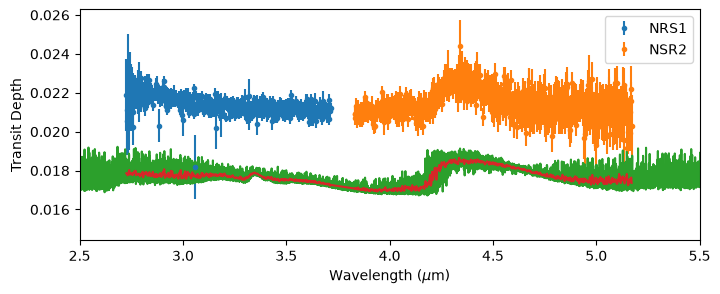

In [7]:
plt.figure(figsize=(8,3))
plt.errorbar(obs._raw[0][:,0],obs._raw[0][:,1], yerr=obs._raw[0][:,2], fmt='.', label='NRS1')
plt.errorbar(obs._raw[1][:,0],obs._raw[1][:,1], yerr=obs._raw[1][:,2], fmt='.', label='NSR2')
plt.plot(10000/out[0], out[1])

plt.plot(out_bin[0], out_bin[1])

plt.xlim(2.5, 5.5)

plt.legend()
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Transit Depth')
plt.show()

In [8]:
from taurex.optimizer import NestleOptimizer

In [15]:
from taurex.optimizer.nestle import NestleOptimizer

opt = NestleOptimizer(num_live_points=50, tol=30.0)
opt.set_model(tm)
opt.set_observed(obs)

opt.enable_fit('Offset_1')
opt.set_boundary('Offset_1', [-1e-2, 1e-2])

opt.enable_fit('EScale_1')
opt.set_boundary('EScale_1', [0.8, 5])

opt.enable_fit('EScale_2')
opt.set_boundary('EScale_2', [0.8, 5])

opt.enable_fit('T')
opt.set_boundary('T', [300, 3000])

opt.enable_fit('H2O')
opt.set_boundary('H2O', [1e-12, 0.1])

opt.enable_fit('CO2')
opt.set_boundary('CO2', [1e-12, 0.1])

opt.enable_fit('planet_radius')
opt.set_boundary('planet_radius', [0.5, 2])

In [ ]:
res = opt.fit()

it=   765 logz=7238.5594972856